# Parcels environment : base

In [78]:
import parcels
import numpy as np
from datetime import timedelta
from glob import glob
import matplotlib.pyplot as plt
import xarray as xr
import os

def u2rho_2d (var_u):
    [Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[:,1:-1]=0.5*(var_u[:,1:]+var_u[:,:-1])
    var_rho[:,0]=var_rho[:,1]
    var_rho[:,-1]=var_rho[:,-2]
    return var_rho
    
def v2rho_2d (var_v):
    [M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[1:-1,:]=0.5*(var_v[1:,:]+var_v[:-1,:])
    var_rho[0,:]=var_rho[1,:]
    var_rho[-1,:]=var_rho[-2,:]
    return var_rho

def u2rho_3d (var_u):
    [N,Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,:,1:-1]=0.5*(var_u[:,:,1:]+var_u[:,:,:-1])
    var_rho[:,:,0]=var_rho[:,:,1]
    var_rho[:,:,-1]=var_rho[:,:,-2]
    return var_rho
    
def v2rho_3d (var_v):
    [N,M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,1:-1,:]=0.5*(var_v[:,1:,:]+var_v[:,:-1,:])
    var_rho[:,0,:]=var_rho[:,1,:]
    var_rho[:,-1,:]=var_rho[:,-2,:]
    return var_rho

def spheric_dist(lat1, lat2, lon1, lon2):
    """
    Compute the spherical distance between two points on Earth.
    
    Parameters:
    lat1, lat2 : array-like
        Latitude of the two points (in degrees).
    lon1, lon2 : array-like
        Longitude of the two points (in degrees).
    
    Returns:
    dist : array-like
        The spherical distance between the points (in meters).
    """
    
    # Earth radius in meters
    R = 6367442.76
    
    # Determine proper longitudinal shift
    l = np.abs(lon2 - lon1)
    l[l >= 180] = 360 - l[l >= 180]
    
    # Convert decimal degrees to radians
    deg2rad = np.pi / 180
    lat1 = lat1 * deg2rad
    lat2 = lat2 * deg2rad
    l = l * deg2rad
    
    # Compute the distances
    dist = R * np.arcsin(np.sqrt(((np.sin(l) * np.cos(lat2)) ** 2) + 
                                 ((np.sin(lat2) * np.cos(lat1)) - 
                                  (np.sin(lat1) * np.cos(lat2) * np.cos(l))) ** 2))
    
    return dist

def spheric_dist_one(lat1, lat2, lon1, lon2):
    """计算两个经纬度点之间的球面距离（标量版）"""
    # 处理经度差
    l = np.abs(lon2 - lon1)
    if l >= 180:
        l = 360 - l
    
    # 转换为弧度
    deg2rad = np.pi / 180
    lat1_rad = lat1 * deg2rad
    lat2_rad = lat2 * deg2rad
    l_rad = l * deg2rad
    
    # 球面距离公式
    distance = 6371 * np.arccos(
        np.sin(lat1_rad) * np.sin(lat2_rad) + 
        np.cos(lat1_rad) * np.cos(lat2_rad) * np.cos(l_rad)
    )
    return distance
    
def transunit_spher2flat(u,v,lat):
    v1=v*1852*60
    u1=u*1852*60*np.cos(lat*np.pi/180)
    return u1,v1

from scipy.interpolate import griddata

def griddata_matlab(lona,lata,ugos,lon_rho,lat_rho):
    points = np.column_stack((lona.ravel(), lata.ravel()))
    values = ugos.ravel()
    
    # 步骤2: 创建目标网格点
    target_points = np.column_stack((lon_rho.ravel(), lat_rho.ravel()))
    
    # 步骤3: 执行插值
    ugos_interp = griddata(points, values, target_points, method='linear')
    
    # 步骤4: 重塑为原始网格形状
    ugos_interp = ugos_interp.reshape(lon_rho.shape)
    return ugos_interp

def snake_scan(matrix):
    """
    ravel() for particles
    matrix: 
        
    flat_array: 1d arrays
    """
    rows, cols = matrix.shape
    result = []
    
    for i in range(rows):
        if i % 2 == 0:  # 偶数行：从左到右
            result.extend(matrix[i, :])
        else:           # 奇数行：从右到左
            result.extend(matrix[i, ::-1])
    
    return np.array(result)

import numpy as np
from scipy.interpolate import griddata

def particle_roughdistr_onetime(lonp, latp, cI, cJ, NP, Range, shape='circle'):
    '''    
    para:
        lonp, latp: grid
        cI, cJ: center of region
        NP: numbers of p
        Range: sub region
        shape:  ('box' or 'circle')
    '''
    squareP = int(np.sqrt(NP))
    Len = int(Range)
    
    # 
    if Len % 2 == 0:
        II = [int(cI - Len/2), int(cI + Len/2)]
        JJ = [int(cJ - Len/2), int(cJ + Len/2)]
    else:
        II = [int(cI - (Len+1)/2), int(cI + Len/2)]
        JJ = [int(cJ - (Len+1)/2), int(cJ + Len/2)]
    
    # sub region
    lonp1 = lonp[JJ[0]:JJ[1], II[0]:II[1]]
    latp1 = latp[JJ[0]:JJ[1], II[0]:II[1]]
    
    # 
    Iin, Jin = np.meshgrid(np.arange(lonp1.shape[0]), 
                          np.arange(lonp1.shape[1]))
    
    points = np.column_stack((Iin.ravel(), Jin.ravel()))

    # choose shape
    if shape == 'box':
        # 
        I1 = np.linspace(0, lonp1.shape[0]-1, squareP)
        J1 = np.linspace(0, lonp1.shape[1]-1, squareP)
        I11, J11 = np.meshgrid(I1, J1)
        
        # 
        lonp2 = griddata(points, lonp1.ravel(), (I11, J11), method='linear')
        latp2 = griddata(points, latp1.ravel(), (I11, J11), method='linear')
        return snake_scan(lonp2), snake_scan(latp2)
    
    elif shape == 'circle':

        center_x = lonp1.shape[0] / 2
        center_y = lonp1.shape[1] / 2
        
        radius = min(lonp1.shape[0], lonp1.shape[1]) / 2
        
        r = radius * np.sqrt(np.random.rand(NP))  #
        theta = 2 * np.pi * np.random.rand(NP)
        
        # 
        x = center_x + r * np.cos(theta)
        y = center_y + r * np.sin(theta)
        
        # 
        points_target = np.column_stack((x, y))
        lonp2 = griddata(points, lonp1.ravel(), points_target, method='linear')
        latp2 = griddata(points, latp1.ravel(), points_target, method='linear')
        
        return lonp2, latp2



def generate_release_times_hourly(total_particles, particles_per_hour, start_time=0):
    """
    :
        total_particles: 
        particles_per_hour: 
        start_time: 
    :
        timep2: 
    """
    total_particles = int(total_particles)
    particles_per_hour = int(particles_per_hour)

    hours_needed = int(np.ceil(total_particles / particles_per_hour))

    timep2 = []
    for hour in range(hours_needed):
        particles_this_hour = min(particles_per_hour, total_particles - len(timep2))
        hour_start = start_time + hour * 3600
        timep2.extend([hour_start] * particles_this_hour)
    
    return np.array(timep2)

In [79]:
grid_dir='/meddy/simingzhang/Data/RB_iceland_data/'
wave_dir='/meddy/simingzhang/Data/Parcels_data/'
# nowave_dir='/meddy/simingzhang/Data/RB_iceland_data/iceland_no_wave/'
grdname='niskin2km_500m_grd.nc'
# hisname_w='z_niskin2km_his_hf_depth_500m_grd.0002.nc'
# hisname_nw='z_niskin2km_his_smooth_depth_500m_grd.0002.nc'

grdname=f'{grid_dir}{grdname}'
# wavename=f'{wave_dir}{hisname_w}'
# nowavename=f'{nowave_dir}{hisname_nw}'

# wavename=f'{wave_dir}wavecase_modified_cg.nc'
# nowavename=f'{wave_dir}nowavecase_modified_cg.nc'
wavename=f'{wave_dir}HIT2dcase_modified_cg_nowin.nc'
nowavename=f'{wave_dir}HIT2dcase_modified_cg_nowin.nc'

In [80]:
# ds=xr.open_dataset(wavename)

In [81]:
# ds

In [82]:
# # 假设 ds 是您的 xarray Dataset 对象
# import re

# # 获取所有以 "Th" 开头的变量名
# th_vars = [var for var in ds.data_vars if re.match(r'^Th\d+', var)]

# # 删除这些变量
# ds = ds.drop_vars(th_vars)

# Parcel
### 1. HIT2D case

In [83]:
wavename
# filenames = {"U": wavename, "V": wavename,"PI2": wavename,"PI4": wavename,"PI6": wavename,"PI8": wavename,"PI10": wavename,
#             "PI12": wavename,"PI16": wavename,"PI20": wavename,"PI30": wavename,"PI50": wavename,"PI60": wavename,"PI100": wavename}

# filenames = {"U": wavename, "V": wavename}

# filenames = {"U": wavename, "V": wavename,"Th1": wavename,"Th2": wavename,"Th3": wavename,"Th4": wavename,"Th5": wavename,
#             "Th6": wavename,"Th7": wavename,"Th8": wavename,"Th9": wavename,"Th10": wavename,"Th11": wavename,"Th12": wavename,
#             "Th13": wavename,"Th14": wavename,"Th15": wavename,"Th16": wavename,"Th17": wavename,"Th18": wavename,"Th21": wavename,
#             "Th24": wavename,"Th27": wavename,"Th30": wavename,"Th33": wavename,"Th36": wavename,"Th39": wavename,"Th42": wavename,
#              "Th45": wavename,"Th48": wavename,"Th54": wavename,"Th60": wavename,"Th66": wavename,"Th72": wavename,"Th78": wavename,
#              "Th84": wavename,"Th90": wavename,"Th96": wavename,"Th102": wavename,"Th108": wavename,"Th114": wavename}
# filenames
variable_names = ["U", "V"]
variable_names += [f"Th{i}" for i in range(2, 19)]
variable_names += [f"Th{i}" for i in [21, 24, 27, 30, 33, 36, 39, 42, 45, 48,
                                      54, 60, 66, 72, 78, 84, 90, 96, 102, 108, 114,120,132,144,156,168,180,192,204,216,228,240,264,
                                     288,312,336,360,384,408,432,456,480,504,512]]
filenames = {var: wavename for var in variable_names}


In [84]:
filenames

{'U': '/meddy/simingzhang/Data/Parcels_data/HIT2dcase_modified_cg_nowin.nc',
 'V': '/meddy/simingzhang/Data/Parcels_data/HIT2dcase_modified_cg_nowin.nc',
 'Th2': '/meddy/simingzhang/Data/Parcels_data/HIT2dcase_modified_cg_nowin.nc',
 'Th3': '/meddy/simingzhang/Data/Parcels_data/HIT2dcase_modified_cg_nowin.nc',
 'Th4': '/meddy/simingzhang/Data/Parcels_data/HIT2dcase_modified_cg_nowin.nc',
 'Th5': '/meddy/simingzhang/Data/Parcels_data/HIT2dcase_modified_cg_nowin.nc',
 'Th6': '/meddy/simingzhang/Data/Parcels_data/HIT2dcase_modified_cg_nowin.nc',
 'Th7': '/meddy/simingzhang/Data/Parcels_data/HIT2dcase_modified_cg_nowin.nc',
 'Th8': '/meddy/simingzhang/Data/Parcels_data/HIT2dcase_modified_cg_nowin.nc',
 'Th9': '/meddy/simingzhang/Data/Parcels_data/HIT2dcase_modified_cg_nowin.nc',
 'Th10': '/meddy/simingzhang/Data/Parcels_data/HIT2dcase_modified_cg_nowin.nc',
 'Th11': '/meddy/simingzhang/Data/Parcels_data/HIT2dcase_modified_cg_nowin.nc',
 'Th12': '/meddy/simingzhang/Data/Parcels_data/HIT2dca

In [85]:
# pip show parcels


In [86]:

# variables = {
#     "U": "u_rho",
#     "V": "v_rho",
# }
# dimensions = {
#     "U": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "V": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
# }


# variables = {
#     "U": "u_rho","V": "v_rho",
#     "Th1": "Th1","Th2": "Th2","Th3": "Th3","Th4": "Th4","Th5": "Th5","Th6": "Th6","Th7": "Th7","Th8": "Th8","Th9": "Th9",
#     "Th10": "Th10","Th11": "Th11","Th12": "Th12","Th13": "Th13","Th14": "Th14","Th15": "Th15","Th16": "Th16","Th17": "Th17","Th18": "Th18",
#     "Th21": "Th21","Th24": "Th24","Th27": "Th27","Th30": "Th30","Th33": "Th33","Th36": "Th36","Th39": "Th39","Th42": "Th42","Th45": "Th45",
#     "Th48": "Th48","Th54": "Th54","Th60": "Th60","Th66": "Th66","Th72": "Th72","Th78": "Th78","Th84": "Th84","Th90": "Th90","Th96": "Th96",
#     "Th102": "Th102","Th108": "Th108","Th114": "Th114",
    
# }
# dimensions = {
#     "U": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "V": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th1": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th2": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th3": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th4": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th5": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th6": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th7": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th8": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th9": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th10": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th11": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th12": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th13": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th14": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th15": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th16": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th17": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th18": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th21": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th24": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th27": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th30": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th33": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th36": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th39": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th42": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th45": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th48": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th54": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th60": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th66": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th72": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th78": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th84": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th90": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th96": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th102": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th108": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "Th114": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},

# }

all_vars = ["U", "V"] + [f"Th{i}" for i in list(range(2, 19)) + [21, 24, 27, 30, 33, 36, 39, 42, 45, 48, 54, 60, 66, 72,
                                                                                78, 84, 90, 96, 102, 108, 114,120,132,144,156,168,180,
                                                                                192,204,216,228,240,264,288,312,336,360,384,408,432,456,
                                                                                480,504,512]]

# 创建 variables 字典
variables = {
    var: "u_rho" if var == "U" else "v_rho" if var == "V" else "Ro" if var == "Ro" else "divof" if var == "divof" else var
    for var in all_vars
}

# 维度模板
dim_template = {
    "lat": "lat_rho",
    "lon": "lon_rho",
    "time": "ocean_time",
    "depth": "depth"
}

# 创建 dimensions 字典
dimensions = {var: dim_template.copy() for var in all_vars}




fieldset = parcels.FieldSet.from_netcdf(filenames, variables, dimensions,allow_time_extrapolation=True, mesh="flat")
# 



In [87]:
# fieldset.U.grid.time[0],fieldset.U.grid.time[-1]
fieldset.U.grid.time.shape,fieldset.V.grid.time.shape

((199,), (199,))

In [88]:
fieldset.U.grid.lon[-1],fieldset.U.grid.lat[0]

(6.270928, 0.0)

# periodic bry

In [89]:
fieldset.add_constant("halo_west", fieldset.U.grid.lon[0])
fieldset.add_constant("halo_east", fieldset.U.grid.lon[-1])
fieldset.add_constant("halo_south", fieldset.U.grid.lat[0])
fieldset.add_constant("halo_north", fieldset.U.grid.lat[-1])

In [90]:
def DeleteParticle(particle, fieldset, time):
    if (particle.lon < math.pi/2) or (particle.lon > math.pi*3/2) or \
       (particle.lat < math.pi/2) or (particle.lat > math.pi*3/2):
        particle.delete()
        
# def SampleT(particle, fieldset, time):
#     particle.ue = fieldset.U[time, particle.depth, particle.lat, particle.lon]
#     particle.ve = fieldset.V[time, particle.depth, particle.lat, particle.lon]


def SampleT(particle, fieldset, time):
    particle.ue = fieldset.U[time, particle.depth, particle.lat, particle.lon]
    particle.ve = fieldset.V[time, particle.depth, particle.lat, particle.lon]
    # particle.th1 = fieldset.Th1[time, particle.depth, particle.lat, particle.lon]
    particle.th2 = fieldset.Th2[time, particle.depth, particle.lat, particle.lon]
    particle.th3 = fieldset.Th3[time, particle.depth, particle.lat, particle.lon]
    particle.th4 = fieldset.Th4[time, particle.depth, particle.lat, particle.lon]
    particle.th5 = fieldset.Th5[time, particle.depth, particle.lat, particle.lon]
    particle.th6 = fieldset.Th6[time, particle.depth, particle.lat, particle.lon]
    particle.th7 = fieldset.Th7[time, particle.depth, particle.lat, particle.lon]
    particle.th8 = fieldset.Th8[time, particle.depth, particle.lat, particle.lon]
    particle.th9 = fieldset.Th9[time, particle.depth, particle.lat, particle.lon]
    particle.th10 = fieldset.Th10[time, particle.depth, particle.lat, particle.lon]
    particle.th11 = fieldset.Th11[time, particle.depth, particle.lat, particle.lon]
    particle.th12 = fieldset.Th12[time, particle.depth, particle.lat, particle.lon]
    particle.th13 = fieldset.Th13[time, particle.depth, particle.lat, particle.lon]
    particle.th14 = fieldset.Th14[time, particle.depth, particle.lat, particle.lon]
    particle.th15 = fieldset.Th15[time, particle.depth, particle.lat, particle.lon]
    particle.th16 = fieldset.Th16[time, particle.depth, particle.lat, particle.lon]
    particle.th17 = fieldset.Th17[time, particle.depth, particle.lat, particle.lon]
    particle.th18 = fieldset.Th18[time, particle.depth, particle.lat, particle.lon]
    particle.th21 = fieldset.Th21[time, particle.depth, particle.lat, particle.lon]
    particle.th24 = fieldset.Th24[time, particle.depth, particle.lat, particle.lon]
    particle.th27 = fieldset.Th27[time, particle.depth, particle.lat, particle.lon]
    particle.th30 = fieldset.Th30[time, particle.depth, particle.lat, particle.lon]
    particle.th33 = fieldset.Th33[time, particle.depth, particle.lat, particle.lon]
    particle.th36 = fieldset.Th36[time, particle.depth, particle.lat, particle.lon]
    particle.th39 = fieldset.Th39[time, particle.depth, particle.lat, particle.lon]
    particle.th42 = fieldset.Th42[time, particle.depth, particle.lat, particle.lon]
    particle.th45 = fieldset.Th45[time, particle.depth, particle.lat, particle.lon]
    particle.th48 = fieldset.Th48[time, particle.depth, particle.lat, particle.lon]
    particle.th54 = fieldset.Th54[time, particle.depth, particle.lat, particle.lon]
    particle.th60 = fieldset.Th60[time, particle.depth, particle.lat, particle.lon]
    particle.th66 = fieldset.Th66[time, particle.depth, particle.lat, particle.lon]
    particle.th72 = fieldset.Th72[time, particle.depth, particle.lat, particle.lon]
    particle.th78 = fieldset.Th78[time, particle.depth, particle.lat, particle.lon]
    particle.th84 = fieldset.Th84[time, particle.depth, particle.lat, particle.lon]
    particle.th90 = fieldset.Th90[time, particle.depth, particle.lat, particle.lon]
    particle.th96 = fieldset.Th96[time, particle.depth, particle.lat, particle.lon]
    particle.th102 = fieldset.Th102[time, particle.depth, particle.lat, particle.lon]
    particle.th108 = fieldset.Th108[time, particle.depth, particle.lat, particle.lon]
    particle.th114 = fieldset.Th114[time, particle.depth, particle.lat, particle.lon]
    particle.th120 = fieldset.Th120[time, particle.depth, particle.lat, particle.lon]
    particle.th132 = fieldset.Th132[time, particle.depth, particle.lat, particle.lon]
    particle.th144 = fieldset.Th144[time, particle.depth, particle.lat, particle.lon]
    particle.th156 = fieldset.Th156[time, particle.depth, particle.lat, particle.lon]
    particle.th168 = fieldset.Th168[time, particle.depth, particle.lat, particle.lon]
    particle.th180 = fieldset.Th180[time, particle.depth, particle.lat, particle.lon]
    particle.th192 = fieldset.Th192[time, particle.depth, particle.lat, particle.lon]
    particle.th204 = fieldset.Th204[time, particle.depth, particle.lat, particle.lon]
    particle.th216 = fieldset.Th216[time, particle.depth, particle.lat, particle.lon]
    particle.th228 = fieldset.Th228[time, particle.depth, particle.lat, particle.lon]
    particle.th240 = fieldset.Th240[time, particle.depth, particle.lat, particle.lon]
    particle.th264 = fieldset.Th264[time, particle.depth, particle.lat, particle.lon]
    particle.th288 = fieldset.Th288[time, particle.depth, particle.lat, particle.lon]
    particle.th312 = fieldset.Th312[time, particle.depth, particle.lat, particle.lon]
    particle.th336 = fieldset.Th336[time, particle.depth, particle.lat, particle.lon]
    particle.th360 = fieldset.Th360[time, particle.depth, particle.lat, particle.lon]
    particle.th384 = fieldset.Th384[time, particle.depth, particle.lat, particle.lon]
    particle.th408 = fieldset.Th408[time, particle.depth, particle.lat, particle.lon]
    particle.th432 = fieldset.Th432[time, particle.depth, particle.lat, particle.lon]
    particle.th456 = fieldset.Th456[time, particle.depth, particle.lat, particle.lon]
    particle.th480 = fieldset.Th480[time, particle.depth, particle.lat, particle.lon]
    particle.th504 = fieldset.Th504[time, particle.depth, particle.lat, particle.lon]
    particle.th512 = fieldset.Th512[time, particle.depth, particle.lat, particle.lon]

def CheckOutOfBounds(particle, fieldset, time):
    if particle.state == StatusCode.ErrorOutOfBounds:
        particle.delete()
def CheckError(particle, fieldset, time):
    if particle.state >= 50:  # This captures all Errors
        particle.delete()

def periodicBC(particle, fieldset, time):
    if particle.lon < fieldset.halo_west:
        particle_dlon += fieldset.halo_east - fieldset.halo_west
    elif particle.lon > fieldset.halo_east:
        particle_dlon -= fieldset.halo_east - fieldset.halo_west

    if particle.lat < fieldset.halo_south:
        particle_dlat += fieldset.halo_north - fieldset.halo_south
    elif particle.lat > fieldset.halo_north:
        particle_dlat -= fieldset.halo_north - fieldset.halo_south

In [91]:
dsg=xr.open_dataset(wavename)

In [92]:
lon_rho=dsg['lon_rho']
lat_rho=dsg['lat_rho']
del dsg

In [124]:
lonp=lon_rho.values
latp=lat_rho.values
# JJ=[Range,287-Range]
# II=[Range,287-Range]
# step=1
# lonp1=lonp[JJ[0]:JJ[1]:step,II[0]:II[1]:step].ravel()
# latp1=latp[JJ[0]:JJ[1]:step,II[0]:II[1]:step].ravel()
step=1
centerpoint=256
# npart=2500
# npart=250*250
# if (np.sqrt(npart) / 2) % 1 == 0:
#     left1=int(np.sqrt(npart)/2)
#     right1=int(np.sqrt(npart)/2)
#     # print(1)
# else:
#     left1=int((np.sqrt(npart)+1)/2)
#     right1=int((np.sqrt(npart)+1)/2)-1
#     # print(2)
lonpp=lonp[127:383,127:383]
latpp=latp[127:383,127:383]
centerpoint=128

lonp1=lonpp[::step,::step].ravel()
latp1=latpp[::step,::step].ravel()

during=0.1*200
lonp1,latp1=particle_roughdistr_onetime(lonp, latp, 256, 256, 2500, 100, shape='box')
outputwavename=f'{wave_dir}HIT2d_pars_P{latp1.shape[0]}T{during}seconds.zarr'

In [125]:
lonp1.shape

(2500,)

# Initial position

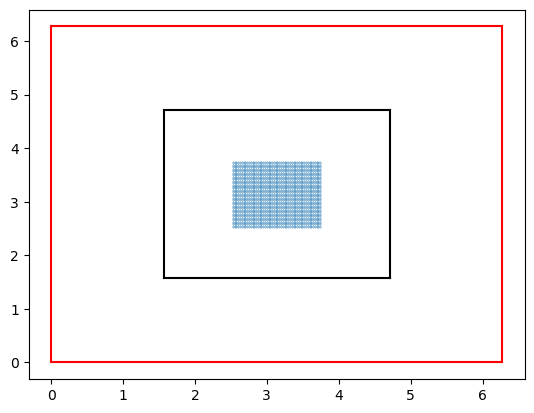

In [126]:
plt.plot(lon_rho.values[0,:],lat_rho.values[0,:],color='r')
plt.plot(lon_rho.values[-1,:],lat_rho.values[-1,:],color='r')
plt.plot(lon_rho.values[:,0],lat_rho.values[:,0],color='r')
plt.plot(lon_rho.values[:,-1],lat_rho.values[:,-1],color='r')
pio2=np.pi/2
pi3o2=np.pi*3/2
plt.plot([pio2,pio2],[pio2,pi3o2],color='k')
plt.plot([pi3o2,pi3o2],[pio2,pi3o2],color='k')
plt.plot([pio2,pi3o2],[pio2,pio2],color='k')
plt.plot([pio2,pi3o2],[pi3o2,pi3o2],color='k')
plt.scatter(lonp1,latp1,s=0.05)

In [127]:
lonp1.shape

(2500,)

# Run Parcels

In [128]:
# from parcels import ErrorCode
# pset = parcels.ParticleSet.from_line(
#     fieldset=fieldset,
#     pclass=parcels.JITParticle,
#     size=1000,
#     start=(-28, 60),
#     finish=(-24, 60),
#     depth=-2,
# )

# ---------------------------------------------------------grid release------------------------------------------------------------
# pset = parcels.ParticleSet.from_list(
#     fieldset=fieldset,
#     pclass=parcels.JITParticle.add_variable("ue").add_variable("ve"),
#     lon=lonp1,
#     lat=latp1,
#     # size=100,                # 粒子总数
#     depth=-2*np.ones(lonp1.shape)                  # 释放深度
# )

# dtlimit ~ 2.5e-4
pset = parcels.ParticleSet.from_list(
    fieldset=fieldset,
    pclass=parcels.JITParticle.add_variable("ue").add_variable("ve").add_variable("th2").add_variable("th3").
    add_variable("th4").add_variable("th5").add_variable("th6").add_variable("th7").add_variable("th8").
    add_variable("th9").add_variable("th10").add_variable("th11").add_variable("th12").add_variable("th13").
    add_variable("th14").add_variable("th15").add_variable("th16").add_variable("th17").add_variable("th18").
    add_variable("th21").add_variable("th24").add_variable("th27").add_variable("th30").add_variable("th33").
    add_variable("th36").add_variable("th39").add_variable("th42").add_variable("th45").add_variable("th48").
    add_variable("th54").add_variable("th60").add_variable("th66").add_variable("th72").add_variable("th78").
    add_variable("th84").add_variable("th90").add_variable("th96").add_variable("th102").add_variable("th108").
    add_variable("th114").add_variable("th120").add_variable("th132").add_variable("th144").add_variable("th156").
    add_variable("th168").add_variable("th180").add_variable("th192").add_variable("th204").add_variable("th216").
    add_variable("th228").add_variable("th240").add_variable("th264").add_variable("th288").add_variable("th312").
    add_variable("th336").add_variable("th360").add_variable("th384").add_variable("th408").add_variable("th432").
    add_variable("th456").add_variable("th480").add_variable("th504").add_variable("th512"),
    lon=lonp1,
    lat=latp1,
    # size=100,                # 粒子总数
    depth=-2*np.ones(lonp1.shape),                  # 释放深度,
    # time=2.5e-4*20**np.ones(lonp1.shape)
)

# pset = parcels.ParticleSet.from_list(
#     fieldset=fieldset,
#     pclass=parcels.JITParticle,
#     lon=lonp1,
#     lat=latp1,
#     # size=100,                # 粒子总数
#     depth=-2*np.ones(lonp1.shape)                  # 释放深度
# )

output_file = pset.ParticleFile(
    name=outputwavename, outputdt=timedelta(seconds=0.1)
)

pset.execute(
    [SampleT,parcels.AdvectionRK4,CheckOutOfBounds],  # simply combine the Kernels in a list
    runtime=timedelta(seconds=20),
    dt=timedelta(seconds=0.05),
    # recovery={ErrorCode.ErrorOutOfBounds: DeleteParticle},  # 禁用自适应步长
    output_file=output_file,
)
#

/home/simingzhang/anaconda3/lib/python3.12/site-packages/parcels/field.py:1180: RuntimeWarning: Sampling of velocities should normally be done using fieldset.UV or fieldset.UVW object; tread carefully
  self._check_velocitysampling()


INFO: Output files are stored in /meddy/simingzhang/Data/Parcels_data/HIT2d_pars_P2500T20.0seconds.zarr.
 35%|██████████████████████████████████████████▋                                                                              | 7.049999999999992/20.0 [01:39<03:02, 14.12s/it]


41

In [129]:
# outputwavename
180*0.00025

0.045

In [130]:
ds = xr.open_zarr(outputwavename)
# from glob import glob
# from os import path

# files = glob(path.join(f'{outputwavename}/', "proc*"))
# ds = xr.concat(
#     [xr.open_zarr(f) for f in files],
#     dim="trajectory",
#     compat="no_conflicts",
#     coords="minimal",
# )
ds

<xarray.Dataset> Size: 39MB
Dimensions:     (trajectory: 2500, obs: 58)
Coordinates:
  * obs         (obs) int32 232B 0 1 2 3 4 5 6 7 8 ... 50 51 52 53 54 55 56 57
  * trajectory  (trajectory) int64 20kB 7500 7501 7502 7503 ... 9997 9998 9999
Data variables: (12/67)
    lat         (trajectory, obs) float32 580kB dask.array<chunksize=(2500, 1), meta=np.ndarray>
    lon         (trajectory, obs) float32 580kB dask.array<chunksize=(2500, 1), meta=np.ndarray>
    th10        (trajectory, obs) float32 580kB dask.array<chunksize=(2500, 1), meta=np.ndarray>
    th102       (trajectory, obs) float32 580kB dask.array<chunksize=(2500, 1), meta=np.ndarray>
    th108       (trajectory, obs) float32 580kB dask.array<chunksize=(2500, 1), meta=np.ndarray>
    th11        (trajectory, obs) float32 580kB dask.array<chunksize=(2500, 1), meta=np.ndarray>
    ...          ...
    th90        (trajectory, obs) float32 580kB dask.array<chunksize=(2500, 1), meta=np.ndarray>
    th96        (trajectory, obs) float32 580kB dask.array<chunksize=(2500, 1), meta=np.ndarray>
    time        (trajectory, obs) timedelta64[ns] 1MB dask.array<chunksize=(2500, 1), meta=np.ndarray>
    ue          (trajectory, obs) float32 580kB dask.array<chunksize=(2500, 1), meta=np.ndarray>
    ve          (trajectory, obs) float32 580kB dask.array<chunksize=(2500, 1), meta=np.ndarray>
    z           (trajectory, obs) float32 580kB dask.array<chunksize=(2500, 1), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        NewParticleSampleTAdvectionRK4CheckOutOfBounds
    parcels_mesh:           flat
    parcels_version:        3.1.2

In [131]:
# ds['time'][0,:].values
# plt.plot(ds['time'].values[250,:],marker='x')

In [132]:
# ds['time'].values[250,:]

# plot traj

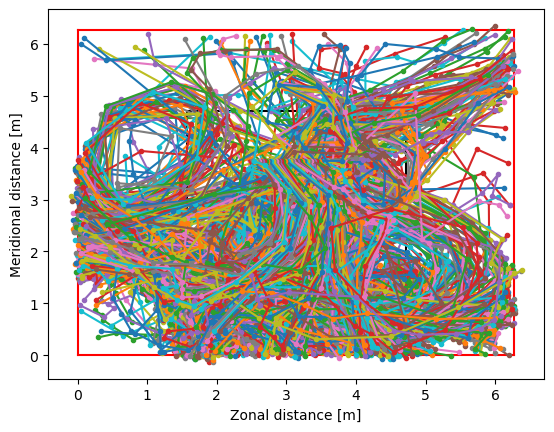

In [133]:
plt.plot(lon_rho.values[0,:],lat_rho.values[0,:],color='r')
plt.plot(lon_rho.values[-1,:],lat_rho.values[-1,:],color='r')
plt.plot(lon_rho.values[:,0],lat_rho.values[:,0],color='r')
plt.plot(lon_rho.values[:,-1],lat_rho.values[:,-1],color='r')
pio2=np.pi/2
pi3o2=np.pi*3/2
plt.plot([pio2,pio2],[pio2,pi3o2],color='k')
plt.plot([pi3o2,pi3o2],[pio2,pi3o2],color='k')
plt.plot([pio2,pi3o2],[pio2,pio2],color='k')
plt.plot([pio2,pi3o2],[pi3o2,pi3o2],color='k')
plt.scatter(lonp1,latp1,s=0.05)
plt.plot(ds.lon.T, ds.lat.T, ".-")
plt.xlabel("Zonal distance [m]")
plt.ylabel("Meridional distance [m]")
plt.show()

# animation

In [137]:
# from IPython.display import HTML
# from matplotlib.animation import FuncAnimation

# fig = plt.figure(figsize=(7, 5), constrained_layout=True)
# ax = fig.add_subplot()

# ax.set_ylabel("Meridional distance [m]")
# ax.set_xlabel("Zonal distance [m]")
# ax.set_xlim(0, 6.28)
# ax.set_ylim(0, 6.28)

# # show only every fifth output (for speed in creating the animation)
# timerange = np.unique(ds["time"].values)[::5]

# # Indices of the data where time = 0
# time_id = np.where(ds["time"] == timerange[0])

# sc = ax.scatter(ds["lon"].values[time_id], ds["lat"].values[time_id])

# t = str(timerange[0].astype("timedelta64[ms]"))
# title = ax.set_title(f"Particles at t = {t}")


# def animate(i):
#     t = str(timerange[i].astype("timedelta64[ms]"))
#     title.set_text(f"Particles at t = {t}")

#     time_id = np.where(ds["time"] == timerange[i])
#     sc.set_offsets(np.c_[ds["lon"].values[time_id], ds["lat"].values[time_id]])


# anim = FuncAnimation(fig, animate, frames=len(timerange), interval=200)

In [136]:
# HTML(anim.to_jshtml())


In [105]:
# anim.save('animation.gif', writer='pillow', fps=20)


In [106]:
# from matplotlib.animation import FuncAnimation
# from IPython.display import HTML
# import matplotlib.pyplot as plt
# import numpy as np
# import matplotlib.patches as patches

# # 设置坐标范围（0到2π）
# lon_min = 0
# lon_max = 6.2832
# lat_min = 0
# lat_max = 6.2832

# # 创建图形
# fig = plt.figure(figsize=(8, 6), constrained_layout=True)
# ax = fig.add_subplot()

# # 设置坐标轴范围和标签
# ax.set_xlim(lon_min, lon_max)
# ax.set_ylim(lat_min, lat_max)
# ax.set_ylabel("Y coordinate")
# ax.set_xlabel("X coordinate")
# ax.set_title("Particle Trajectories in [0, 2π] Domain")

# # 设置坐标轴刻度
# ax.set_xticks(np.linspace(0, 6.2832, 5))
# ax.set_yticks(np.linspace(0, 6.2832, 5))
# ax.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'])
# ax.set_yticklabels(['0', 'π/2', 'π', '3π/2', '2π'])

# # 显示网格
# ax.grid(True, linestyle='--', alpha=0.7)

# # 添加边界框
# rect = patches.Rectangle((0, 0), 6.2832, 6.2832, linewidth=1, edgecolor='r', facecolor='none')
# ax.add_patch(rect)

# # 获取时间范围
# timerange = np.unique(ds["time"].values)[::1]

# # 创建初始散点图
# time_id = np.where(ds["time"] == timerange[0])
# sc = ax.scatter(ds["lon"].values[time_id], ds["lat"].values[time_id], s=10, alpha=0.7, color='blue')

# # 添加时间文本
# time_text = ax.text(0.05, 0.95, '', transform=ax.transAxes, fontsize=12, 
#                     bbox=dict(facecolor='white', alpha=0.8))

# def animate(i):
#     # 更新粒子位置
#     time_id = np.where(ds["time"] == timerange[i])
#     sc.set_offsets(np.c_[ds["lon"].values[time_id], ds["lat"].values[time_id]])
    
#     # 更新时间文本
#     t = str(timerange[i].astype("timedelta64[ms]"))
#     time_text.set_text(f"Time: {t}")
    
#     return sc, time_text

# # 创建动画

# anim = FuncAnimation(fig, animate, frames=len(timerange), interval=1)

In [107]:
np.nanmax(ds['ve'].values)

14.843346

In [108]:
# HTML(anim.to_jshtml())


# transform velocity

In [109]:
# ue,ve=transunit_spher2flat(ds['ue'].values,ds['ve'].values,ds['lat'].values)
# ds['ue'].values=ue
# ds['ve'].values=ve

In [110]:
# f'{outputwavename[37:-5]}.nc'

In [111]:
ds.to_netcdf(f'{outputwavename[:-5]}.nc')

/home/simingzhang/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: RuntimeWarning: overflow encountered in multiply
  return bound(*args, **kwds)
/home/simingzhang/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: RuntimeWarning: overflow encountered in multiply
  return bound(*args, **kwds)
/home/simingzhang/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: RuntimeWarning: overflow encountered in multiply
  return bound(*args, **kwds)
/home/simingzhang/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: RuntimeWarning: overflow encountered in multiply
  return bound(*args, **kwds)
/home/simingzhang/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: RuntimeWarning: overflow encountered in multiply
  return bound(*args, **kwds)
/home/simingzhang/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: RuntimeWarning: overflow encountered in multiply
  return bound(*args, **kwds)
/hom

In [112]:
# ds['ue'].values

In [113]:
f'{outputwavename[:-5]}.nc'

'/meddy/simingzhang/Data/Parcels_data/HIT2d_pars_P2500T20.0seconds.nc'